<a href="https://colab.research.google.com/github/DeepanshuSharma1607/tech_stuck/blob/main/pytorch_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohammedalrajeh/quran-recitations-for-audio-classification")

print("Path to dataset files:", path)

100%|██████████| 2.12G/2.12G [00:56<00:00, 40.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mohammedalrajeh/quran-recitations-for-audio-classification/versions/1


In [ ]:
import torch
from torch import nn
from torch.optim import Adam
import librosa
from torch.utils.data import Dataset , DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import time
from skimage.transform import resize

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
os.path.join(path , "Dataset")

'/root/.cache/kagglehub/datasets/mohammedalrajeh/quran-recitations-for-audio-classification/versions/1/Dataset'

In [ ]:
data_df = pd.read_csv(os.path.join(path , "files_paths.csv"))

In [ ]:
data_df

,FilePath,Class
0,./Dataset/Mohammed_Aluhaidan/lohaidan_171.wav,Mohammed_Aluhaidan
1,./Dataset/Mohammed_Aluhaidan/lohaidan_159.wav,Mohammed_Aluhaidan
2,./Dataset/Mohammed_Aluhaidan/lohaidan_401.wav,Mohammed_Aluhaidan
3,./Dataset/Mohammed_Aluhaidan/lohaidan_367.wav,Mohammed_Aluhaidan
4,./Dataset/Mohammed_Aluhaidan/lohaidan_373.wav,Mohammed_Aluhaidan
...,...,...
6682,./Dataset/Abdullah_Albuaijan/Abdullah_148.wav,Abdullah_Albuaijan
6683,./Dataset/Abdullah_Albuaijan/Abdullah_014.wav,Abdullah_Albuaijan
6684,./Dataset/Abdullah_Albuaijan/Abdullah_028.wav,Abdullah_Albuaijan
6685,./Dataset/Abdullah_Albuaijan/Abdullah_202.wav,Abdullah_Albuaijan


In [ ]:
data_df['Class'].value_counts()

,count
Class,
Saud_Alshuraim,696
Saad_Alghamdi,688
AbdulRahman_Alsudais,648
Yasser_Aldossary,576
Ali_Alhothaify,576
Bander_Balilah,576
Maher_Almuaiqly,576
Abdullah_Albuaijan,504
Mohammed_Ayoub,480


In [ ]:
data_df['FilePath']=os.path.join(path , "Dataset")+data_df["FilePath"].str[1:]

In [ ]:
data_df.head()

,FilePath,Class
0,/root/.cache/kagglehub/datasets/mohammedalraje...,Mohammed_Aluhaidan
1,/root/.cache/kagglehub/datasets/mohammedalraje...,Mohammed_Aluhaidan
2,/root/.cache/kagglehub/datasets/mohammedalraje...,Mohammed_Aluhaidan
3,/root/.cache/kagglehub/datasets/mohammedalraje...,Mohammed_Aluhaidan
4,/root/.cache/kagglehub/datasets/mohammedalraje...,Mohammed_Aluhaidan


In [ ]:
data_df.shape

(6687, 2)

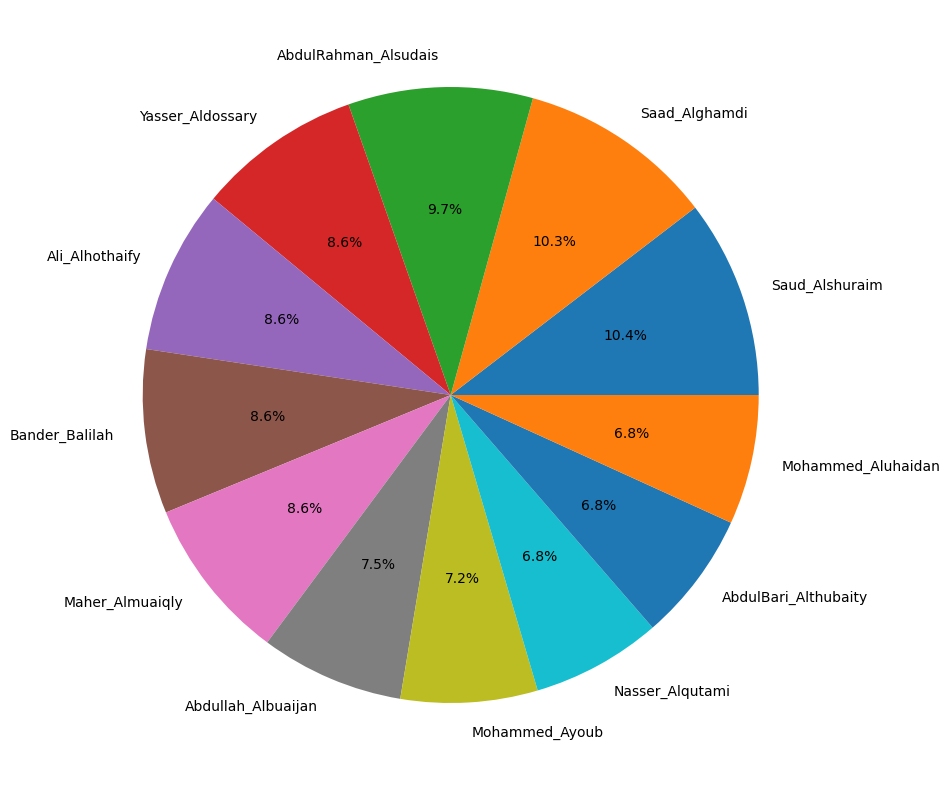

In [ ]:
plt.figure(figsize=(10,10))
plt.pie(data_df['Class'].value_counts(),labels=data_df['Class'].value_counts().index,autopct='%1.1f%%')
plt.show()

In [ ]:
label_encoder = LabelEncoder()
data_df['Class'] = label_encoder.fit_transform(data_df['Class'])
train = data_df.sample(frac = 0.7,random_state = 7)
test =  data_df.drop(train.index)

val = test.sample(frac = 0.5,random_state = 7)
test = test.drop(val.index)

train.shape , test.shape , val.shape

((4681, 2), (1003, 2), (1003, 2))

In [ ]:
class CustomAudioDataset(Dataset):
  def __init__(self , dataframe):
    self.dataframe = dataframe

    self.labels = torch.tensor(
            dataframe['Class'].values,
            dtype=torch.long
        )

    self.audios = [(torch.Tensor(self.get_spectrogram(path)).type(torch.FloatTensor)) for path in dataframe['FilePath']]


  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self,idx):
    img_path = self.dataframe.iloc[idx , 0]
    label = torch.Tensor(self.labels[idx]).to(device)
    audio = self.audios[idx].unsqueeze(0).to(device)
    return audio , label

  def get_spectrogram(self , file_path):
    sr = 22050
    dur = 5

    img_height = 128
    img_width = 256

    signal , sr = librosa.load(file_path , sr = sr , duration = dur)

    spec = librosa.feature.melspectrogram(y = signal , sr = sr , n_fft = 2048 , hop_length=512 , n_mels = 128)

    spec_db = librosa.power_to_db(spec , ref = np.max)

    img = librosa.util.fix_length(spec_db , size = (dur*sr) // 512+1)

    img = resize(img , (img_height , img_width) , anti_aliasing = True)

    return img

In [ ]:
train_dataset = CustomAudioDataset(dataframe = train)
test_dataset = CustomAudioDataset(dataframe = test)
val_dataset = CustomAudioDataset(dataframe = val)

In [ ]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 25

In [ ]:
train_loader = DataLoader(train_dataset , batch_size = BATCH_SIZE , shuffle = True)
test_loader = DataLoader(test_dataset , batch_size = BATCH_SIZE , shuffle = True)
val_loader = DataLoader(val_dataset , batch_size = BATCH_SIZE , shuffle = True)

In [ ]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(1,16,kernel_size = 3 , padding = 1)
    self.conv2 =nn.Conv2d(16,32,kernel_size = 3 , padding = 1)
    self.conv3 =nn.Conv2d(32,64,kernel_size = 3 , padding = 1)
    self.pooling = nn.MaxPool2d(2,2)
    self.relu = nn.ReLU()
    self.flatten = nn.Flatten()
    self.linear1 = nn.Linear((64*16*32),4096)
    self.linear2 = nn.Linear(4096,1024)
    self.linear3 = nn.Linear(1024,512)
    self.output = nn.Linear(512,len(data_df['Class'].unique()))
    self.dropout = nn.Dropout(0.5)

  def forward(self , x):
    x=self.conv1(x)
    x=self.pooling(x)

    x=self.conv2(x)
    x=self.pooling(x)

    x=self.conv3(x)
    x=self.pooling(x)

    x = self.relu(x)

    x = x.view(x.size(0), -1)
    x=self.flatten(x)

    x=self.linear1(x)
    x=self.dropout(x)

    x=self.linear2(x)
    x=self.dropout(x)

    x=self.linear3(x)
    x=self.dropout(x)

    x=self.output(x)

    return x


In [ ]:
model = Net().to(device)
print(model)

Net(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear1): Linear(in_features=32768, out_features=4096, bias=True)
  (linear2): Linear(in_features=4096, out_features=1024, bias=True)
  (linear3): Linear(in_features=1024, out_features=512, bias=True)
  (output): Linear(in_features=512, out_features=12, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [ ]:
from torchsummary import summary
summary(model , (1,128,256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 128, 256]             160
         MaxPool2d-2          [-1, 16, 64, 128]               0
            Conv2d-3          [-1, 32, 64, 128]           4,640
         MaxPool2d-4           [-1, 32, 32, 64]               0
            Conv2d-5           [-1, 64, 32, 64]          18,496
         MaxPool2d-6           [-1, 64, 16, 32]               0
              ReLU-7           [-1, 64, 16, 32]               0
           Flatten-8                [-1, 32768]               0
            Linear-9                 [-1, 4096]     134,221,824
          Dropout-10                 [-1, 4096]               0
           Linear-11                 [-1, 1024]       4,195,328
          Dropout-12                 [-1, 1024]               0
           Linear-13                  [-1, 512]         524,800
          Dropout-14                  [

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters() , lr = LR)

In [ ]:
total_loss_train_plot = []
total_loss_val_plot = []
total_acc_train_plot = []
total_acc_val_plot = []

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0
  total_loss_val = 0
  total_acc_val = 0

  model.train()

  for x , y in train_loader:
    output = model(x)
    train_loss = criterion(output , y)
    total_loss_train += train_loss.item()

    train_acc = (torch.argmax(output , axis = 1) == y).sum().item()
    total_acc_train += train_acc

    train_loss.backward()
    optimizer.step()
    optimizer.zero_grad()

  model.eval()

  with torch.no_grad():
    for x , y in val_loader:
      output = model(x)
      val_loss = criterion(output , y)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(output , axis = 1) == y).sum().item()
      total_acc_val += val_acc

  avg_train_loss = total_loss_train / len(train_loader)
  avg_val_loss = total_loss_val / len(val_loader)

  train_accuracy = total_acc_train / len(train_loader.dataset)
  val_accuracy = total_acc_val / len(val_loader.dataset)
  total_loss_train_plot.append(round(avg_train_loss, 4))
  total_loss_val_plot.append(round(avg_val_loss, 4))
  total_acc_train_plot.append(round(train_accuracy, 4))
  total_acc_val_plot.append(round(val_accuracy, 4))
  print(
      f"Epoch [{epoch+1}/{EPOCHS}] "
      f"Train Loss: {avg_train_loss:.4f} "
      f"Train Acc: {train_accuracy:.4f} "
      f"Val Loss: {avg_val_loss:.4f} "
      f"Val Acc: {val_accuracy:.4f}"
  )

Epoch [1/25] Train Loss: 2.6212 Train Acc: 0.4443 Val Loss: 0.5268 Val Acc: 0.8714
Epoch [2/25] Train Loss: 0.4307 Train Acc: 0.8701 Val Loss: 0.2323 Val Acc: 0.9322
Epoch [3/25] Train Loss: 0.2446 Train Acc: 0.9308 Val Loss: 0.4166 Val Acc: 0.8963
Epoch [4/25] Train Loss: 0.1915 Train Acc: 0.9421 Val Loss: 0.1977 Val Acc: 0.9432
Epoch [5/25] Train Loss: 0.1215 Train Acc: 0.9624 Val Loss: 0.1553 Val Acc: 0.9561
Epoch [6/25] Train Loss: 0.1293 Train Acc: 0.9665 Val Loss: 0.1501 Val Acc: 0.9511
Epoch [7/25] Train Loss: 0.1090 Train Acc: 0.9692 Val Loss: 0.1363 Val Acc: 0.9631
Epoch [8/25] Train Loss: 0.1054 Train Acc: 0.9705 Val Loss: 0.2832 Val Acc: 0.9432
Epoch [9/25] Train Loss: 0.1418 Train Acc: 0.9601 Val Loss: 0.1816 Val Acc: 0.9432
Epoch [10/25] Train Loss: 0.0874 Train Acc: 0.9761 Val Loss: 0.1605 Val Acc: 0.9631
Epoch [11/25] Train Loss: 0.1070 Train Acc: 0.9709 Val Loss: 0.1646 Val Acc: 0.9541
Epoch [12/25] Train Loss: 0.0602 Train Acc: 0.9833 Val Loss: 0.0920 Val Acc: 0.9771
E

In [ ]:
with torch.no_grad():
    total_loss_test = 0
    total_acc_test = 0
    for x , y in test_loader:
      output = model(x)
      test_loss = criterion(output , y)
      total_loss_test += test_loss.item()

      test_acc = (torch.argmax(output , axis = 1) == y).sum().item()
      total_acc_test += test_acc

print(f"""Total Accuracy Score is {round((total_acc_test/test_dataset.__len__()*100),4)}""")
print(total_acc_test / len(test_loader.dataset))

Total Accuracy Score is 91.5254
0.9152542372881356


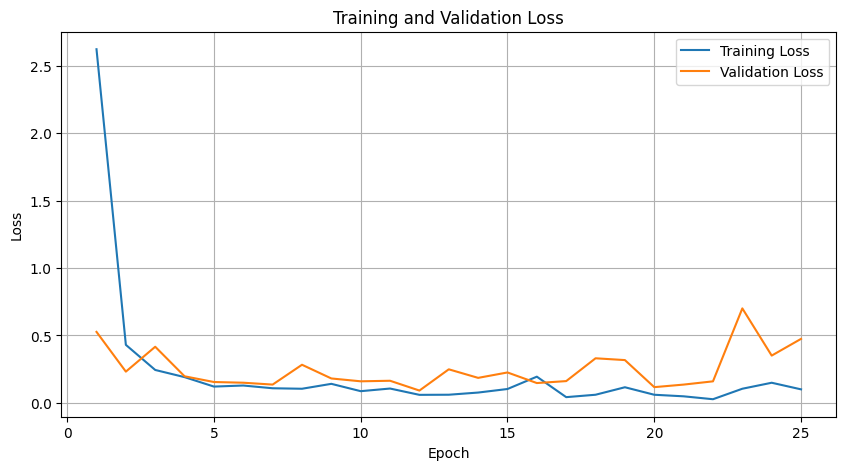

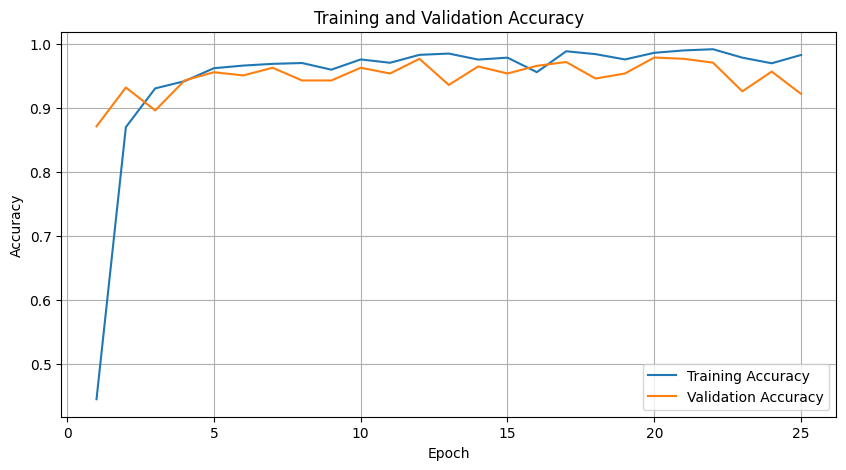

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

# ================= LOSS PLOT =================

plt.figure(figsize=(10, 5))

plt.plot(
    epochs,
    total_loss_train_plot,
    label="Training Loss"
)

plt.plot(
    epochs,
    total_loss_val_plot,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True)
plt.show()


# ================= ACCURACY PLOT =================

plt.figure(figsize=(10, 5))

plt.plot(
    epochs,
    total_acc_train_plot,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    total_acc_val_plot,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid(True)
plt.show()